Credit Card Fraud Detection using Logistic Regression and Undersampling

### Basic Libraries import

In [ ]:
import kagglehub
mlg_ulb_creditcardfraud_path = kagglehub.dataset_download(
    'mlg-ulb/creditcardfraud'
)

print('Data source import complete.')

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Data source import complete.


In [3]:
import os

print(mlg_ulb_creditcardfraud_path)
print(os.listdir(mlg_ulb_creditcardfraud_path))

/kaggle/input/creditcardfraud
['creditcard.csv']


Dataset load

In [4]:
import pandas as pd

df = pd.read_csv("/kaggle/input/creditcardfraud/creditcard.csv")

print(df.head())
print("Shape:", df.shape)

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

To check if data set are in missing/null values.

In [5]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


Checking the basic information of Data Set

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Statistical information

In [7]:
df.describe().round(2)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,...,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00
mean,94813.86,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,...,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,88.35,0.00
std,47488.15,1.96,1.65,1.52,1.42,1.38,1.33,1.24,1.19,1.10,...,0.73,0.73,0.62,0.61,0.52,0.48,0.40,0.33,250.12,0.04
min,0.00,-56.41,-72.72,-48.33,-5.68,-113.74,-26.16,-43.56,-73.22,-13.43,...,-34.83,-10.93,-44.81,-2.84,-10.30,-2.60,-22.57,-15.43,0.00,0.00
25%,54201.50,-0.92,-0.60,-0.89,-0.85,-0.69,-0.77,-0.55,-0.21,-0.64,...,-0.23,-0.54,-0.16,-0.35,-0.32,-0.33,-0.07,-0.05,5.60,0.00
50%,84692.00,0.02,0.07,0.18,-0.02,-0.05,-0.27,0.04,0.02,-0.05,...,-0.03,0.01,-0.01,0.04,0.02,-0.05,0.00,0.01,22.00,0.00
75%,139320.50,1.32,0.80,1.03,0.74,0.61,0.40,0.57,0.33,0.60,...,0.19,0.53,0.15,0.44,0.35,0.24,0.09,0.08,77.16,0.00
max,172792.00,2.45,22.06,9.38,16.88,34.80,73.30,120.59,20.01,15.59,...,27.20,10.50,22.53,4.58,7.52,3.52,31.61,33.85,25691.16,1.00


Normal vs Fraud count

In [12]:
print("Normal Transactions:", df['Class'].value_counts()[0])
print("Fraud Transactions:", df['Class'].value_counts()[1])

Normal Transactions: 284315
Fraud Transactions: 492


Features(X) and Target (y) are Separating Now

In [14]:
X = df.drop(columns=["Class"])
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (284807, 30)
Target shape: (284807,)


Train/Test Split after that

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (199364, 30)
X_test: (85443, 30)
y_train: (199364,)
y_test: (85443,)


Logistic Regression Model

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Prediction

In [31]:
y_pred = model.predict(X_test)

print("Prediction Completed!")
print("First 10 prediction:", y_pred[:10])

Prediction Completed!
First 10 prediction: [0 0 0 0 0 0 0 0 0 0]


Confusion Matrix

In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[85276    19]
 [   51    97]]


Now check the Accuracy

In [34]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_test)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 1.0
Accuracy (%): 100.0


Classification Report

In [37]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.66      0.73       148

    accuracy                           1.00     85443
   macro avg       0.92      0.83      0.87     85443
weighted avg       1.00      1.00      1.00     85443



ROC-AUC

In [38]:
from sklearn.metrics import roc_auc_score

y_pred_probability = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_probability)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.9343360008111752


Fraud vs Normal Count
(Actual mein 0 = Normal kitne
Actual mein 1 = Fraud kitne
Model ne 0 kitne predict kiye
Model ne 1 kitne predict kiye)

In [39]:
print("Actual transactions:")
print(y_test.value_counts())

print("\nPredicted transactions:")
print(pd.Series(y_pred).value_counts())

Actual transactions:
Class
0    85295
1      148
Name: count, dtype: int64

Predicted transactions:
0    85327
1      116
Name: count, dtype: int64


Fraud Performance


Precision → Out of all the transactions predicted as fraud, how many were actually fraud.

Recall → Out of all the actual fraud transactions, how many were correctly detected by the model.

F1-Score → The balance between Precision and Recall.

In [40]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Precision: 0.8362068965517241
Recall: 0.6554054054054054
F1-Score: 0.7348484848484849


All Important Metrics

In [41]:
print("Model Performance")
print("------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)
print("ROC-AUC  :", auc)

Model Performance
------------------
Accuracy : 1.0
Precision: 0.8362068965517241
Recall   : 0.6554054054054054
F1-Score : 0.7348484848484849
ROC-AUC  : 0.9343360008111752


Confusion Matrix Visualization

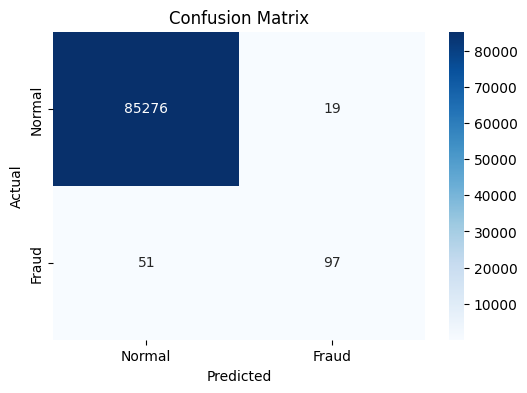

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Comparing the amount value of normal transactions versus fraud

Non Fraud %  99.83
Fraud %     0.17


/tmp/ipykernel_908/364246290.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['Class'].value_counts().index,y=df['Class'].value_counts(), palette=["C1", "C8"])


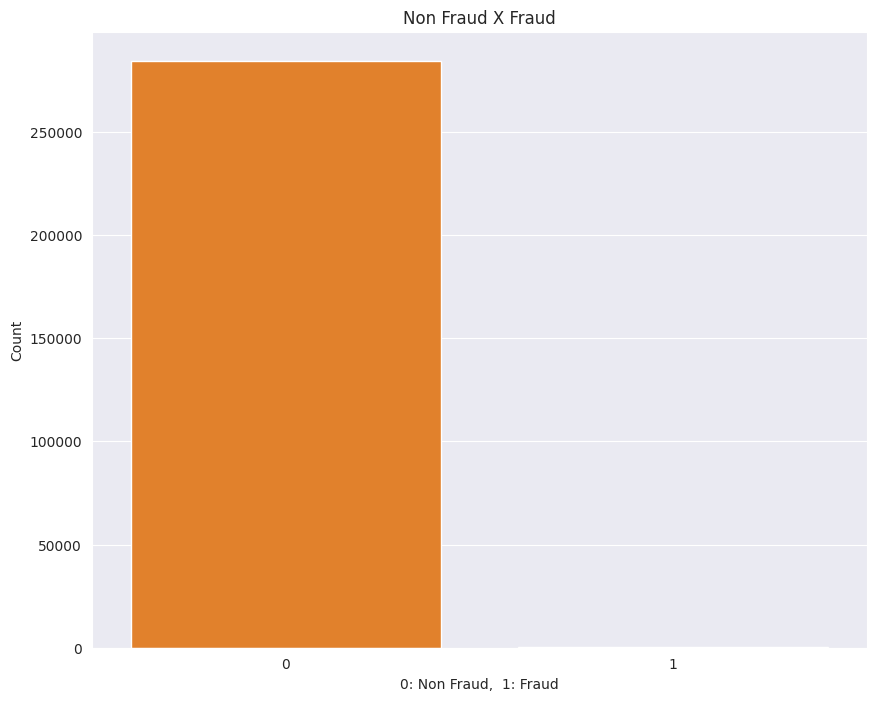

In [52]:
plt.figure(figsize=(10,8))
sns.set_style('darkgrid')
sns.barplot(x=df['Class'].value_counts().index,y=df['Class'].value_counts(), palette=["C1", "C8"])
plt.title('Non Fraud X Fraud')
plt.ylabel('Count')
plt.xlabel('0: Non Fraud,  1: Fraud')
print ('Non Fraud % ',round(df['Class'].value_counts()[0]/len(df)*100,2))
print ('Fraud %    ',round(df['Class'].value_counts()[1]/len(df)*100,2));

Undersampled Logistic Regression

In [65]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    C=1,
    penalty='l2',
    max_iter=1000
)

clf.fit(
    X_undersampled_train,
    Y_undersampled_train
)

print("Model training completed!")

Model training completed!


In [58]:
from sklearn import metrics

In [62]:
import numpy as np

In [63]:
# Fraud transactions
fraud_records = len(df[df.Class == 1])

# Fraud aur non-fraud ke indexes
fraud_indices = df[df.Class == 1].index
not_fraud_indices = df[df.Class == 0].index

# Fraud transactions ke equal normal transactions select karo
under_sample_indices = np.random.choice(
    not_fraud_indices,
    fraud_records,
    replace=False
)

# Balanced dataset create karo
df_undersampled = df.iloc[
    np.concatenate([fraud_indices, under_sample_indices]),
    :
]

# Features aur target
X_undersampled = df_undersampled.iloc[:, 1:30]
Y_undersampled = df_undersampled.Class

# Train-test split
X_undersampled_train, X_undersampled_test, \
Y_undersampled_train, Y_undersampled_test = train_test_split(
    X_undersampled,
    Y_undersampled,
    test_size=0.30,
    random_state=42,
    stratify=Y_undersampled
)

print("Undersampled data:", df_undersampled.shape)
print("X_train:", X_undersampled_train.shape)
print("X_test :", X_undersampled_test.shape)
print("\nClass distribution:")
print(Y_undersampled_train.value_counts())

Undersampled data: (984, 31)
X_train: (688, 29)
X_test : (296, 29)

Class distribution:
Class
1    344
0    344
Name: count, dtype: int64


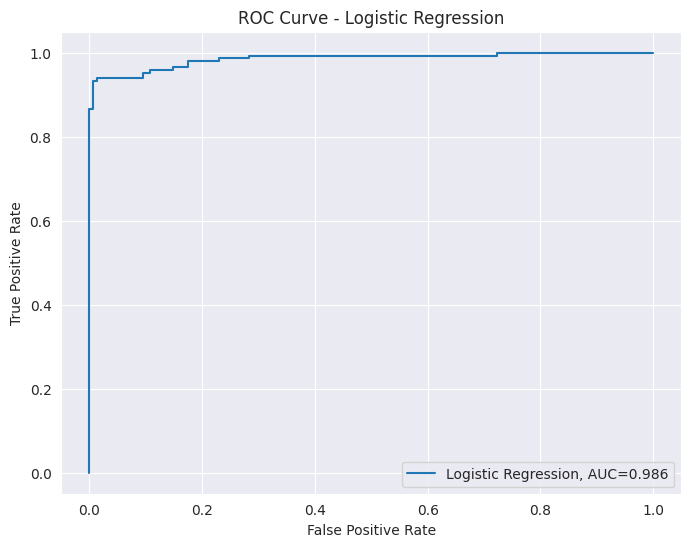

ROC-AUC Score: 0.986


In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import matplotlib.pyplot as plt

clf = LogisticRegression(
    C=1,
    penalty='l2',
    max_iter=1000
)

clf.fit(
    X_undersampled_train,
    Y_undersampled_train
)

y_pred = clf.predict(X_undersampled_test)

y_pred_probability = clf.predict_proba(
    X_undersampled_test
)[:, 1]

fpr, tpr, thresholds = metrics.roc_curve(
    Y_undersampled_test,
    y_pred_probability
)

auc = metrics.roc_auc_score(
    Y_undersampled_test,
    y_pred_probability
)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    label="Logistic Regression, AUC=" + str(round(auc, 3))
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc=4)
plt.show()

print("ROC-AUC Score:", round(auc, 3))

### Conclusion

In this project, Logistic Regression was used to detect fraudulent credit card transactions. The dataset contained 284,807 transactions, including 284,315 normal transactions and 492 fraudulent transactions. The dataset was highly imbalanced, with fraud transactions representing only 0.17% of the total transactions.

To handle this class imbalance, an undersampling technique was applied to create a more balanced dataset containing equal numbers of normal and fraudulent transactions. A Logistic Regression model was then trained on the undersampled data.

The model was evaluated **using a confusion matrix, accuracy, precision, recall, F1-score, and ROC-AUC**. These metrics provide a better understanding of the model's ability to identify fraudulent transactions than accuracy alone.

Overall, this project demonstrates how Logistic Regression and data preprocessing techniques such as undersampling can be used for credit card fraud detection. The results also show the importance of using appropriate evaluation metrics when working with highly imbalanced datasets.